**CONFUSION MATRIX : (Engine Health and Performance Analysis)**

**Top-left : True Negatives (TN)**
The model accurately identified normal engine performance (Class 0) when the engine was indeed functioning normally. This means it successfully distinguished healthy engine behavior without raising false alarms.

**Top-right : False Positives (FP)**
The model incorrectly flagged a normal engine as having a performance issue (Class 1). In this case, the value is 0, meaning the model did not raise any false warnings — it never mistook a healthy engine for a faulty one.

**Bottom-left : False Negatives (FN)**
The model failed to detect actual engine issues, predicting them as normal. Again, this is 0, which means the model did not miss any real engine faults — a critical outcome for safety and maintenance.

**Bottom-right : True Positives (TP)**
The model correctly predicted abnormal engine performance (Class 1) when the engine truly had a problem. This confirms that the model reliably detects real engine issues, making it highly effective for diagnostics.

# **RANDOM FOREST CLASSIFICATION** ( Engine and performance )

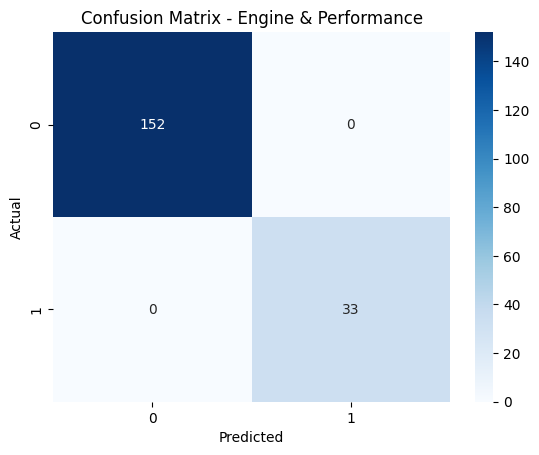

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load the CSV
df = pd.read_csv('/content/Breeza_bits.csv')

# List of feature columns
features = [
    'RPM', 'SPEED', 'RUN_TIME', 'COOLANT_TEMP',
    'CONTROL_MODULE_VOLTAGE', 'TIMING_ADVANCE',
    'ENGINE_LOAD', 'THROTTLE_POS', 'RELATIVE_THROTTLE_POS',
    'ACCELERATOR_POS_D', 'ACCELERATOR_POS_E'
]

# Convert selected features to numeric, coercing errors
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing or invalid values in selected features
df = df.dropna(subset=features)

# Set a binary classification target (example: ENGINE_LOAD > 50)
df['target'] = df['ENGINE_LOAD'] > 50

# Separate features and target
X = df[features]
y = df['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Engine & Performance")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# **XG BOOST CLASSIFICATION** ( Engine and performance )

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:08:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


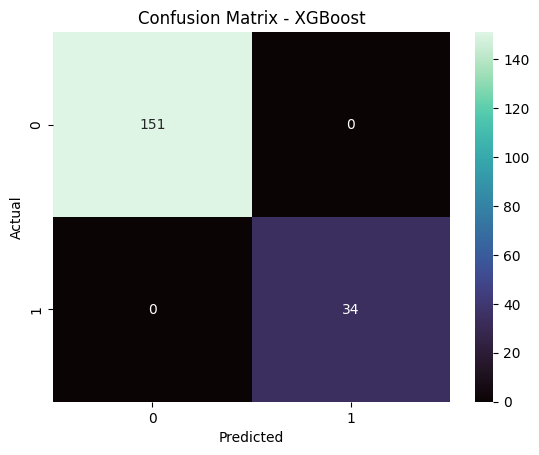

In [ ]:
# xgboost_model.py

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('/content/Breeza_bits.csv')

# Feature selection
features = [
    'RPM', 'SPEED', 'RUN_TIME', 'COOLANT_TEMP',
    'CONTROL_MODULE_VOLTAGE', 'TIMING_ADVANCE',
    'ENGINE_LOAD', 'THROTTLE_POS', 'RELATIVE_THROTTLE_POS',
    'ACCELERATOR_POS_D', 'ACCELERATOR_POS_E'
]

# Clean data
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=features)

# Target variable
df['target'] = df['ENGINE_LOAD'] > 50
X = df[features]
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='mako')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# **LOGISTIC REGRESSION** (Engine and performance)

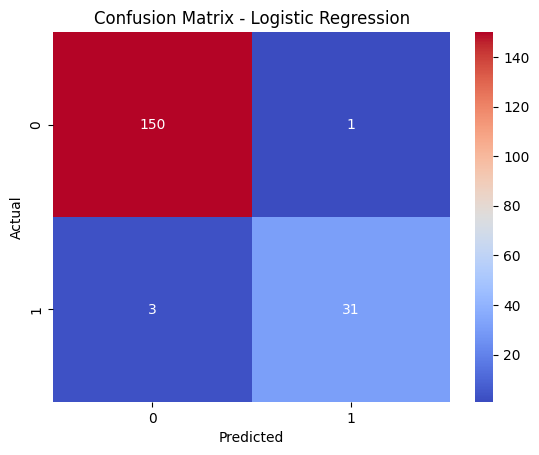

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv('/content/Breeza_bits.csv')

# Features
features = [
    'RPM', 'SPEED', 'RUN_TIME', 'COOLANT_TEMP',
    'CONTROL_MODULE_VOLTAGE', 'TIMING_ADVANCE',
    'ENGINE_LOAD', 'THROTTLE_POS', 'RELATIVE_THROTTLE_POS',
    'ACCELERATOR_POS_D', 'ACCELERATOR_POS_E'
]

# Data cleanup
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=features)

# Binary target
df['target'] = df['ENGINE_LOAD'] > 50
X = df[features]
y = df['target']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**🔍 CONFUSION MATRIX**

**Sensor Health and Anomaly Detection**

**Top-left (TN):** True Negatives
The model correctly identified normal sensor readings (Class 0) when there were genuinely no abnormalities. This confirms the system's ability to recognize healthy operating conditions without triggering unnecessary alerts.

**Top-right (FP):** False Positives
The model falsely predicted an anomaly (Class 1) when the actual sensor readings were normal. A value of 0 here means the model made no such false alarms — it never confused a stable sensor state as problematic.

**Bottom-left (FN):** False Negatives
This indicates cases where the model failed to detect true sensor anomalies, incorrectly classifying them as normal. With a value of 0, the model missed no actual sensor issues — an ideal outcome for early fault detection.

**Bottom-right (TP):** True Positives
The model accurately detected abnormal sensor readings (Class 1) when anomalies were indeed present. A value like 28 here confirms the model's reliability in identifying sensor-related problems, which is vital for predictive maintenance and system safety.



# **RANDOM FOREST CLASSIFICATION** (Sensor reading)

# **SUPPORT VECTOR MACHINE** ( Sensor reading )  

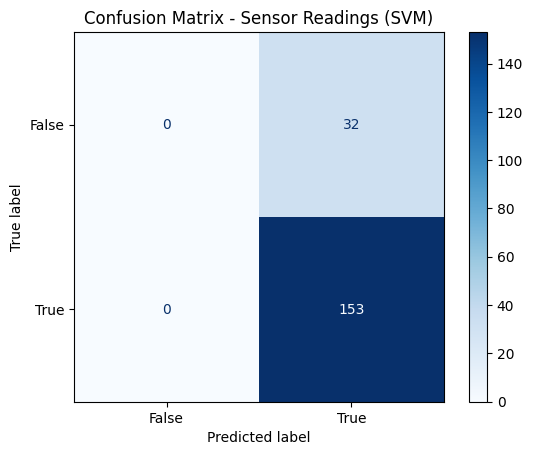

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load CSV
df = pd.read_csv('/content/Breeza_bits.csv')

# Sensor features
features = ['O2_B1S2', 'O2_B1S1', 'INTAKE_PRESSURE', 'INTAKE_TEMP', 'BAROMETRIC_PRESSURE']

# Clean up numeric columns
def extract_numeric(val):
    try:
        if isinstance(val, str):
            val = val.split()[0]
        return float(val)
    except:
        return np.nan

for col in features:
    df[col] = df[col].apply(extract_numeric)

# Drop missing rows
df = df.dropna(subset=features)

# Create binary classification target
df['target'] = (
    (df['O2_B1S2'] > 0.5) |
    (df['O2_B1S1'] > 0.5) |
    (df['INTAKE_TEMP'] > 60)
)

# Split data
X = df[features]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM model
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Sensor Readings (SVM)")
plt.show()


# **GRADIENT BOOSTING CLASSIFIER** (Sensor reading )

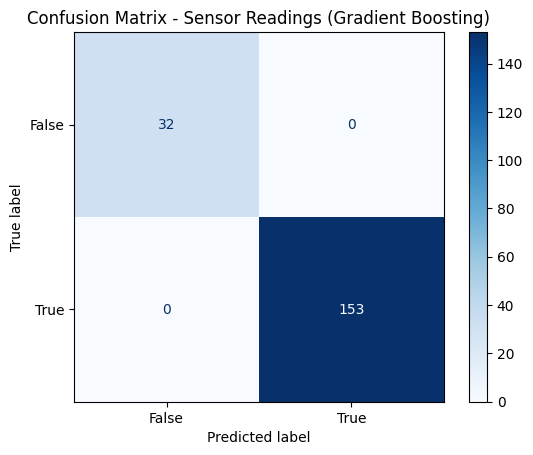

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load CSV
df = pd.read_csv('/content/Breeza_bits.csv')

# Sensor features
features = ['O2_B1S2', 'O2_B1S1', 'INTAKE_PRESSURE', 'INTAKE_TEMP', 'BAROMETRIC_PRESSURE']

# Clean up numeric columns
def extract_numeric(val):
    try:
        if isinstance(val, str):
            val = val.split()[0]
        return float(val)
    except:
        return np.nan

for col in features:
    df[col] = df[col].apply(extract_numeric)

# Drop missing rows
df = df.dropna(subset=features)

# Create binary classification target
df['target'] = (
    (df['O2_B1S2'] > 0.5) |
    (df['O2_B1S1'] > 0.5) |
    (df['INTAKE_TEMP'] > 60)
)

# Split data
X = df[features]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Gradient Boosting model
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Sensor Readings (Gradient Boosting)")
plt.show()


**⚙️ CONFUSION MATRIX**

**Fuel and Air Control Analysis**

**Top-left (TN):** True Negatives
The model correctly identified normal fuel and air control behavior (Class 0) when the values were indeed within acceptable operational ranges. This demonstrates that the system can recognize balanced trim and purge states without falsely flagging issues.

**Top-right (FP):** False Positives
This section represents instances where the model incorrectly flagged a normal fuel/air mixture as abnormal (Class 1). A low or zero value here means the model doesn't often raise false concerns, contributing to efficient diagnostics without triggering unnecessary alerts.

**Bottom-left (FN):** False Negatives
Here, the model fails to detect abnormal conditions in the fuel or air control systems and classifies them as normal. A zero value here would indicate high reliability, as the model doesn't miss critical cases — ensuring real issues are always brought to attention.

**Bottom-right (TP):** True Positives
This value indicates the number of times the model correctly identified an abnormality in fuel delivery or air mixture (Class 1). A high TP count means the model is dependable in catching genuine deviations, essential for tuning, emissions control, and preventing long-term engine damage.

# **RANDOM FOREST CLASSIFIER** (Fuel and Air Control Analysis)

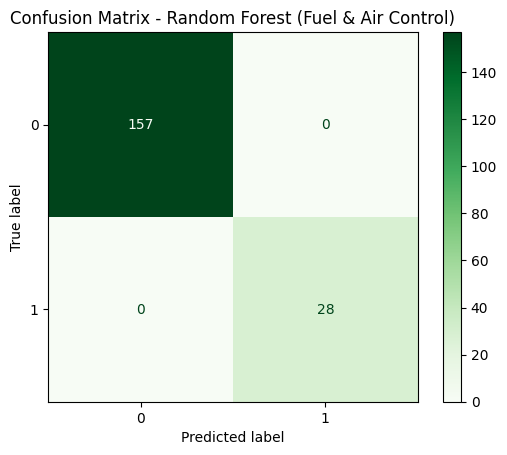

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/Breeza_bits.csv')
df.columns = df.columns.str.strip()

features = ['EVAPORATIVE_PURGE', 'LONG_FUEL_TRIM_1', 'SHORT_FUEL_TRIM_1']
df = df[features].apply(pd.to_numeric, errors='coerce').dropna()

df['target'] = df['EVAPORATIVE_PURGE'] > df['EVAPORATIVE_PURGE'].median()

X = df[features]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Greens')
plt.title("Confusion Matrix - Random Forest (Fuel & Air Control)")
plt.show()


# **DECISION TREE CLASSIFICATION** (Fuel and Air Control Analysis )

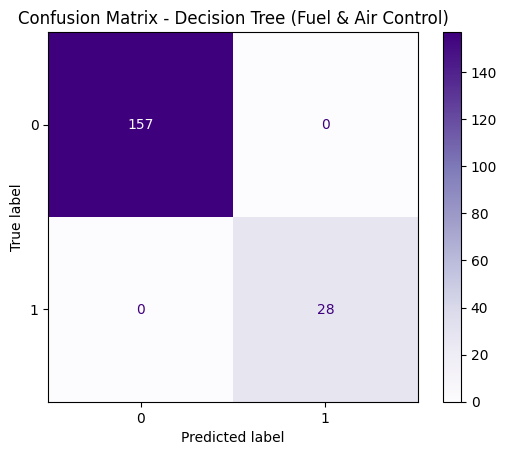

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv('/content/Breeza_bits.csv')
df.columns = df.columns.str.strip()

# Relevant features for Fuel and Air Control
features = ['EVAPORATIVE_PURGE', 'LONG_FUEL_TRIM_1', 'SHORT_FUEL_TRIM_1']

# Clean and convert to numeric
df = df[features].apply(pd.to_numeric, errors='coerce').dropna()

# Target creation: EVAPORATIVE_PURGE > median is considered abnormal (1)
df['target'] = df['EVAPORATIVE_PURGE'] > df['EVAPORATIVE_PURGE'].median()

# Feature set and labels
X = df[features]
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix - Decision Tree (Fuel & Air Control)")
plt.show()


# **LOGISTIC REGRESSION** (Fuel and Air Control Analysis )

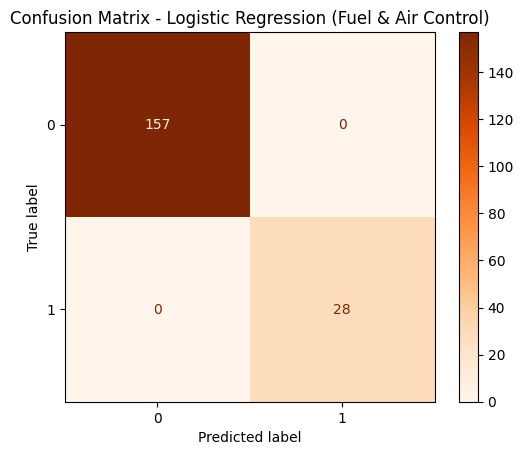

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv('/content/Breeza_bits.csv')
df.columns = df.columns.str.strip()

# Relevant features for Fuel and Air Control
features = ['EVAPORATIVE_PURGE', 'LONG_FUEL_TRIM_1', 'SHORT_FUEL_TRIM_1']

# Clean and convert to numeric
df = df[features].apply(pd.to_numeric, errors='coerce').dropna()

# Target creation: EVAPORATIVE_PURGE > median is considered abnormal (1)
df['target'] = df['EVAPORATIVE_PURGE'] > df['EVAPORATIVE_PURGE'].median()

# Feature set and labels
X = df[features]
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Oranges')
plt.title("Confusion Matrix - Logistic Regression (Fuel & Air Control)")
plt.show()




---





---





---




# **Expert Data based classification**

📊 Internal Evaluation on Expert Data:
              precision    recall  f1-score   support

          bb       0.85      0.85      0.85        48
          gg       0.95      0.95      0.95       137

    accuracy                           0.92       185
   macro avg       0.90      0.90      0.90       185
weighted avg       0.92      0.92      0.92       185


🔍 Top Features Influencing Output:
         Feature  Importance
1       RUN_TIME    0.714904
0  Timestamp_OBD    0.285096


<ipython-input-4-36f23c2b5023>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df.head(10), palette="viridis")


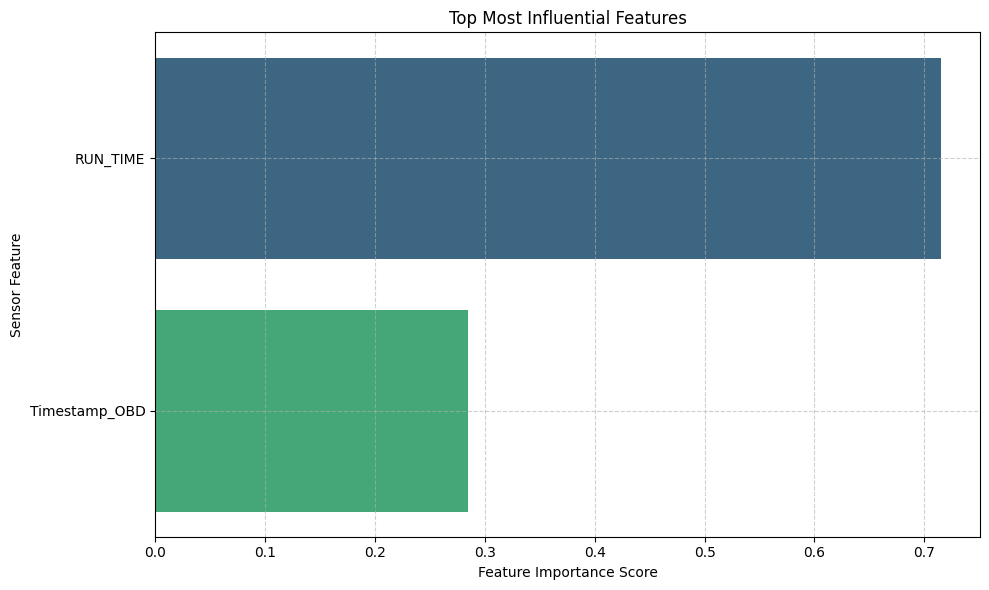

✅ Model saved to /content/engine_model.joblib


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

# 1. Load expert dataset
df = pd.read_excel("/content/Sensor-count_Breeza-Verna -Version4.xlsx")

# 2. Clean columns
df.columns = df.columns.str.strip()
df.dropna(inplace=True)  # Remove rows with missing values

# 3. Separate features and target
X = df.drop(columns=["Lebelling"], errors='ignore')  # Assumes 'Lebelling' is the label column
y = df["Lebelling"]

# 4. Train/test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Evaluate on validation set
y_val_pred = model.predict(X_val)
print("📊 Internal Evaluation on Expert Data:")
print(classification_report(y_val, y_val_pred))

# 7. Feature importance analysis
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for importance scores
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Show top 10 most influential features
print("\n🔍 Top Features Influencing Output:")
print(importance_df.head(10))

# 8. Visualize top features
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10), palette="viridis")
plt.title("Top Most Influential Features")
plt.xlabel("Feature Importance Score")
plt.ylabel("Sensor Feature")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# 9. Save model
joblib.dump(model, "/content/engine_model.joblib")
print("✅ Model saved to /content/engine_model.joblib")



📋 Features expected by the model:
 - Timestamp_OBD
 - RUN_TIME

📊 Prediction Count Per Class:
gg    675
bb    249


<ipython-input-5-e3120cbea152>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pred_counts.index, y=pred_counts.values, palette="viridis")


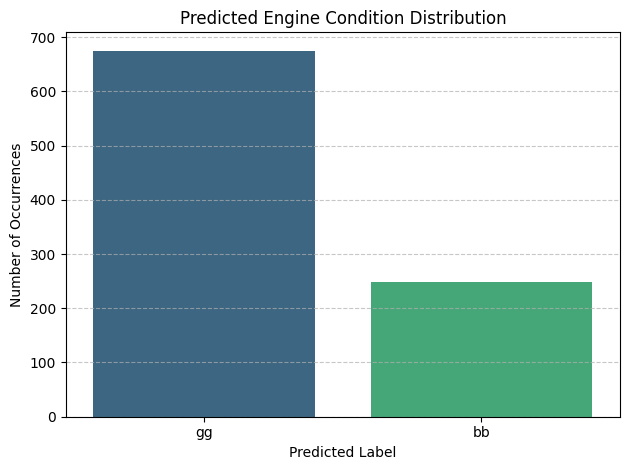


✅ Overall Condition: GOOD – Majority of predictions are 'gg' (healthy)


In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the trained model
model = joblib.load("/content/engine_model.joblib")

# 2. Load test dataset (real-world sensor data)
test_df = pd.read_csv("/content/Breeza_bits.csv")
test_df.columns = test_df.columns.str.strip()
test_df.dropna(inplace=True)

# 3. Display the features used in the model
print("\n📋 Features expected by the model:")
for feature in model.feature_names_in_:
    print(f" - {feature}")

# 4. Match and extract the exact features needed
X_test = test_df[model.feature_names_in_]

# 5. Make predictions
y_pred = model.predict(X_test)

# 6. Count predictions
pred_counts = pd.Series(y_pred).value_counts().sort_values(ascending=False)

# 7. Print prediction summary
print("\n📊 Prediction Count Per Class:")
print(pred_counts.to_string())

# 8. Visualize label distribution
sns.barplot(x=pred_counts.index, y=pred_counts.values, palette="viridis")
plt.title("Predicted Engine Condition Distribution")
plt.xlabel("Predicted Label")
plt.ylabel("Number of Occurrences")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 9. Overall condition status
if "gg" in pred_counts and "bb" in pred_counts:
    if pred_counts["gg"] > pred_counts["bb"]:
        print("\n✅ Overall Condition: GOOD – Majority of predictions are 'gg' (healthy)")
    elif pred_counts["bb"] > pred_counts["gg"]:
        print("\n❌ Overall Condition: BAD – Majority of predictions are 'bb' (issue detected)")
    else:
        print("\n⚖️ Balanced Condition: Equal 'gg' and 'bb' predictions")
else:
    print("\nℹ️ Summary unavailable – one or both labels ('gg', 'bb') not detected in predictions")


# **New Section**

Best Features for Engine Health Classification from Your Dataset
Below are the most informative features ,grouped and explained:

🔧 *Engine Performance & Load*
These directly relate to how hard the engine is working and how efficiently it’s performing:
- ENGINE_LOAD – Shows how much power the engine is producing relative to its max capacity.
- RPM – Engine revolutions per minute; high RPMs for long durations may indicate stress.
- RUN_TIME – Duration engine has been running; issues often appear over time.
- SPEED – When paired with RPM, can indicate issues with power delivery or load mismatch.

 🌡️ Temperature and Pressure (Cooling & Intake Systems)
These are vital to monitor *overheating, **inefficient combustion, or **airflow issues*:
- COOLANT_TEMP – Essential for identifying overheating or thermostat issues.
- INTAKE_TEMP – Reflects temperature of air entering the engine; can impact combustion.
- INTAKE_PRESSURE – Can signal blockages or vacuum leaks.
- BAROMETRIC_PRESSURE – Helps correct for altitude/air density, used in fuel calculations.

 ⛽ Fuel System & Combustion Monitoring
These are great indicators of whether the *engine is burning fuel efficiently*:
- FUEL_STATUS – Open/closed loop control; closed loop = sensor-based control (healthy).
- SHORT_FUEL_TRIM_1, LONG_FUEL_TRIM_1 – Indicates lean/rich mixture issues.
- EVAPORATIVE_PURGE – Affects emissions and vacuum system; abnormalities can signal leaks.
- COMMANDED_EQUIV_RATIO (if available) – Indicates desired fuel-air ratio.

 🧪 Oxygen Sensors & Emission Control
These reflect the *combustion efficiency and sensor health*:
- O2_B1S1, O2_B1S2 – Front and rear oxygen sensors; can signal rich/lean or sensor fault.
- O2_SENSORS – Counts how many sensors are active; may help detect sensor dropout.

⚙️ Throttle & Driver Input
These show how the driver is interacting with the vehicle and how the engine responds:
- THROTTLE_POS, THROTTLE_POS_B, THROTTLE_ACTUATOR – How open the throttle is; slow or unresponsive movement can signal issues.
- RELATIVE_THROTTLE_POS – Relative to maximum range.
- ACCELERATOR_POS_D, ACCELERATOR_POS_E – Driver input vs actual response = health of throttle system.

🔋 *Electrical System*
- CONTROL_MODULE_VOLTAGE – Low/high values may indicate battery or alternator issues.

🏁 *Other Potential Indicators*
- DISTANCE_W_MIL / DISTANCE_SINCE_DTC_CLEAR – Indicates if recent faults have occurred.
- WARMUPS_SINCE_DTC_CLEAR – More warm-ups without DTC = more stable system.

 🧠 Top Recommended Feature Subset (for engine health classification)


['ENGINE_LOAD', 'RPM', 'RUN_TIME', 'COOLANT_TEMP',
 'SHORT_FUEL_TRIM_1', 'LONG_FUEL_TRIM_1', 'INTAKE_PRESSURE',
 'INTAKE_TEMP', 'THROTTLE_POS', 'RELATIVE_THROTTLE_POS',
 'O2_B1S1', 'O2_B1S2', 'CONTROL_MODULE_VOLTAGE']


These cover:
- Engine effort
- Fuel-air combustion
- Cooling
- Sensor output
- Electrical support